In [1]:
# Imports Python's random module for generating random values and making weighted random choices
import random

# Imports mathematical functions
import math

# Imports dataclass to create structured classes for perfumes and agents
from dataclasses import dataclass

# Imports type hints used to describe lists and dictionaries
from typing import List, Dict

# Imports pandas for storing and analysing the simulation results in a DataFrame
import pandas as pd

# Imports matplotlib for creating graphs and visualising the simulation results
import matplotlib.pyplot as plt

In [2]:
# Uses a dataclass to automatically create and organise the data stored for each perfume
@dataclass
class Perfume:

    # Unique identification number for the perfume
    perfume_id: int

    # Name of the perfume
    name: str

    # Scent family the perfume belongs to
    scent_family: str

    # Price of the perfume
    price: float

    # Stores the perfume's popularity from the previous round, starting at 1
    popularity: int = 1

    # Keeps a cumulative count of how many times the perfume is selected
    total_choices: int = 0

In [3]:
# Uses a dataclass to represent each consumer agent in the simulation
@dataclass
class Agent:

    # Unique identification number for each consumer agent
    agent_id: int

    # Stores the agent's preferred scent family
    preferred_scent: str

    # Controls how strongly the agent responds to perfume price
    price_sensitivity: float

    # Controls how strongly the agent is influenced by perfume popularity
    social_susceptibility: float

    # Stores the name of the perfume most recently selected by the agent
    last_choice: str = None

    # Calculates how closely a perfume's scent matches the agent's preferred scent
    def scent_match_score(self, perfume: Perfume) -> float:
        """
        Exact match = 5
        Related / close scent = 3
        No close match = 1
        """

        # Defines which scent families are considered related to each preference
        scent_map = {
            "sweet": ["sweet", "amber", "fresh"],
            "oud": ["oud", "tobacco", "amber"],
            "fresh": ["fresh", "sweet", "amber"],
            "amber": ["amber", "sweet", "oud", "tobacco"],
            "tobacco": ["tobacco", "oud", "amber"]
        }

        # Gives the highest score when the perfume exactly matches the preferred scent
        if perfume.scent_family == self.preferred_scent:
            return 5.0

        # Gives a medium score when the perfume belongs to a related scent family
        elif perfume.scent_family in scent_map[self.preferred_scent]:
            return 3.0

        # Gives the lowest score when the scent is not a close match
        else:
            return 1.0

    # Calculates an overall preference score for a perfume
    def calculate_score(self, perfume: Perfume) -> float:
        """
        Version 2 score:
        score = scent_match + social_effect - price_penalty + noise
        """

        # Gets the perfume's scent compatibility score for this agent
        scent_match = self.scent_match_score(perfume)

        # Stronger social influence than version 1
        # More popular perfumes receive a larger social effect for susceptible agents
        social_effect = perfume.popularity * self.social_susceptibility * 0.15

        # Price penalty
        # Higher prices create a larger penalty, especially for price-sensitive agents
        price_penalty = (perfume.price * self.price_sensitivity) / 120

        # Random behavioural noise
        # Adds variation so agents do not behave completely deterministically
        noise = random.uniform(-0.5, 0.5)

        # Combines scent, social influence, price and random variation into one score
        score = scent_match + social_effect - price_penalty + noise

        # Returns the calculated score for this perfume
        return score

    # Chooses one perfume from the available perfumes
    def choose_perfume(self, perfumes: List[Perfume]) -> Perfume:
        """
        Weighted choice:
        Agents are more likely to choose high-scoring perfumes,
        but not always the exact same one.
        """

        # Calculates a score for every available perfume
        scores = [self.calculate_score(perfume) for perfume in perfumes]

        # Convert scores into positive weights
        # Finds the lowest score so all weights can be shifted above zero
        min_score = min(scores)

        # Adds 0.1 so that even the lowest-scoring perfume still has a chance of selection
        adjusted_scores = [score - min_score + 0.1 for score in scores]

        # Randomly selects one perfume using the adjusted scores as probability weights
        chosen_perfume = random.choices(perfumes, weights=adjusted_scores, k=1)[0]

        # Records the perfume selected by the agent
        self.last_choice = chosen_perfume.name

        # Returns the selected perfume
        return chosen_perfume

In [4]:
# Main simulation class that controls the agents, perfumes, rounds and results
class PerfumeSimulationV2:

    # Initialises the simulation with 100 agents, 50 rounds and a fixed random seed
    def __init__(self, num_agents: int = 100, num_rounds: int = 50, seed: int = 42):

        # Stores the number of consumer agents used in the simulation
        self.num_agents = num_agents

        # Stores the number of rounds the simulation will run for
        self.num_rounds = num_rounds

        # Sets the random seed so the simulation can produce reproducible results
        random.seed(seed)

        # Defines the five scent families available in the simulation
        self.scents = ["sweet", "oud", "fresh", "amber", "tobacco"]

        # Creates the five perfume products with an ID, name, scent family and price
        self.perfumes = [
            Perfume(1, "La Luna", "sweet", 130),
            Perfume(2, "Black Carbon Diamond", "oud", 110),
            Perfume(3, "White F", "fresh", 70),
            Perfume(4, "Reef 31", "amber", 70),
            Perfume(5, "Mexican Tobacco", "tobacco", 120),
        ]

        # Creates the consumer agents using the create_agents method
        self.agents = self.create_agents()

        # Creates an empty list that will store the results from each simulation round
        self.history = []

    # Creates the required number of consumer agents
    def create_agents(self) -> List[Agent]:

        # Creates an empty list for storing the agents
        agents = []

        # Repeats the process for each agent required by the simulation
        for i in range(1, self.num_agents + 1):

            # Creates an agent with randomly generated consumer characteristics
            agent = Agent(

                # Gives each agent a unique ID
                agent_id=i,

                # Randomly assigns one of the five preferred scent families
                preferred_scent=random.choice(self.scents),

                # Randomly assigns price sensitivity between 0.1 and 1.0
                price_sensitivity=round(random.uniform(0.1, 1.0), 2),

                # Randomly assigns social susceptibility between 0.1 and 1.0
                social_susceptibility=round(random.uniform(0.1, 1.0), 2)
            )

            # Adds the newly created agent to the agents list
            agents.append(agent)

        # Returns the completed list of agents
        return agents

    # Runs the simulation for the specified number of rounds
    def run(self):

        # Repeats the simulation process for every round
        for round_num in range(1, self.num_rounds + 1):

            # Starts each perfume's selection count at zero for the current round
            round_counts = {perfume.name: 0 for perfume in self.perfumes}

            # Allows every consumer agent to make one perfume choice in each round
            for agent in self.agents:

                # Calls the agent's decision-making method to select a perfume
                chosen_perfume = agent.choose_perfume(self.perfumes)

                # Adds one to the selected perfume's count for the current round
                round_counts[chosen_perfume.name] += 1

                # Adds one to the perfume's cumulative number of choices
                chosen_perfume.total_choices += 1

            # Update popularity for next round
            # Sets each perfume's popularity to its number of selections in this round
            for perfume in self.perfumes:
                perfume.popularity = round_counts[perfume.name]

            # Creates a row containing the current round number
            row = {"Round": round_num}

            # Adds the selection counts for all five perfumes to the row
            row.update(round_counts)

            # Stores the completed round results in the simulation history
            self.history.append(row)

    # Converts the stored simulation history into a Pandas DataFrame
    def get_results_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.history)

    # Creates a line graph showing perfume selections across all simulation rounds
    def plot_popularity_trends(self):

        # Gets the simulation results as a DataFrame
        df = self.get_results_dataframe()

        # Creates a figure for the graph
        plt.figure(figsize=(12, 6))

        # Creates a separate line showing the selections for each perfume over time
        for perfume in self.perfumes:
            plt.plot(df["Round"], df[perfume.name], label=perfume.name)

        # Adds labels, title, legend and grid to make the graph easier to interpret
        plt.xlabel("Round")
        plt.ylabel("Number of Selections")
        plt.title("Perfume Popularity Over Time - Version 2")
        plt.legend()
        plt.grid(True)

        # Displays the completed graph
        plt.show()

    # Creates a bar chart showing cumulative selections for each perfume
    def plot_final_market_share(self):

        # Creates a list containing the names of all perfumes
        names = [perfume.name for perfume in self.perfumes]

        # Creates a list containing each perfume's cumulative number of selections
        totals = [perfume.total_choices for perfume in self.perfumes]

        # Creates the bar chart
        plt.figure(figsize=(10, 6))
        plt.bar(names, totals)

        # Adds labels and a title to the chart
        plt.xlabel("Perfume")
        plt.ylabel("Total Choices")
        plt.title("Final Market Share by Perfume - Version 2")

        # Rotates the perfume names slightly so they are easier to read
        plt.xticks(rotation=20)

        # Displays the completed bar chart
        plt.show()

    # Prints a text summary of the final results for every perfume
    def print_final_summary(self):

        # Prints the heading for the summary
        print("Final Summary - Version 2")
        print("-" * 45)

        # Goes through each perfume and prints its final information
        for perfume in self.perfumes:
            print(f"{perfume.name}:")
            print(f"  Scent Family: {perfume.scent_family}")
            print(f"  Price: £{perfume.price}")
            print(f"  Final Popularity: {perfume.popularity}")
            print(f"  Total Choices: {perfume.total_choices}")

In [5]:
# Creates the simulation using 100 consumer agents, 50 rounds and a fixed random seed of 42
simulation_v2 = PerfumeSimulationV2(num_agents=100, num_rounds=50, seed=42)

# Runs the simulation so that every agent makes one perfume choice during each round
simulation_v2.run()

In [6]:
# Converts the stored simulation history into a Pandas DataFrame for viewing and analysis
results_df_v2 = simulation_v2.get_results_dataframe()

# Displays the first 10 rounds of simulation results
results_df_v2.head(10)

,Round,La Luna,Black Carbon Diamond,White F,Reef 31,Mexican Tobacco
0,1,19,17,16,20,28
1,2,11,27,16,27,19
2,3,6,21,15,35,23
3,4,6,19,18,42,15
4,5,10,18,17,42,13
5,6,18,14,14,36,18
6,7,9,16,19,40,16
7,8,12,19,14,41,14
8,9,15,24,15,34,12
9,10,8,25,13,37,17


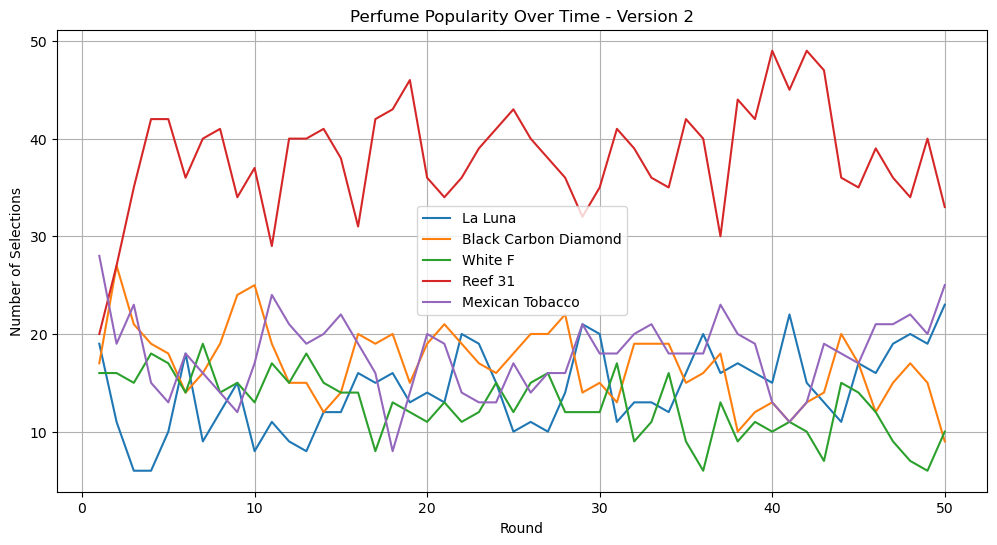

In [7]:
# Creates and displays a line graph showing how each perfume's selections change across the simulation rounds
simulation_v2.plot_popularity_trends()

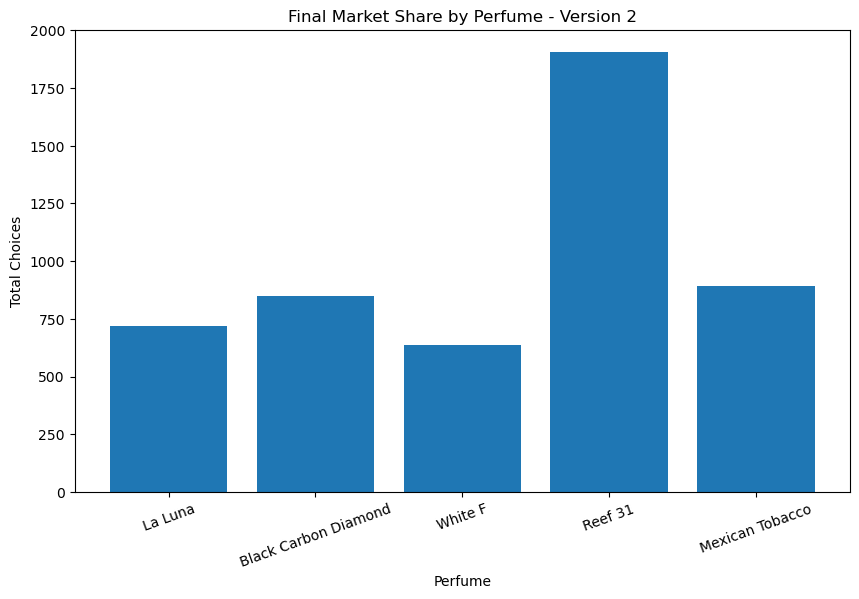

In [8]:
# Creates and displays a bar chart showing the total number of selections each perfume received across all simulation rounds
simulation_v2.plot_final_market_share()

In [9]:
# Prints a final text summary showing each perfume's scent family, price, final-round popularity and total selections
simulation_v2.print_final_summary()

Final Summary - Version 2
---------------------------------------------
La Luna:
  Scent Family: sweet
  Price: £130
  Final Popularity: 23
  Total Choices: 717
Black Carbon Diamond:
  Scent Family: oud
  Price: £110
  Final Popularity: 9
  Total Choices: 847
White F:
  Scent Family: fresh
  Price: £70
  Final Popularity: 10
  Total Choices: 636
Reef 31:
  Scent Family: amber
  Price: £70
  Final Popularity: 33
  Total Choices: 1906
Mexican Tobacco:
  Scent Family: tobacco
  Price: £120
  Final Popularity: 25
  Total Choices: 894


In [10]:
# Exports the complete simulation results DataFrame to a CSV file without including the DataFrame index
results_df_v2.to_csv("perfume_simulation_v2_results.csv", index=False)

# Confirms that the results have been saved successfully
print("Results saved successfully.")

Results saved successfully.


In [11]:
# Creates a scenario version of the simulation where the range of social susceptibility can be changed
class PerfumeSimulationScenario:

    # Initialises the scenario with agents, rounds, random seed and a chosen social susceptibility range
    def __init__(self, num_agents: int = 100, num_rounds: int = 50, seed: int = 42, social_range=(0.1, 1.0)):

        # Stores the number of consumer agents
        self.num_agents = num_agents

        # Stores the number of simulation rounds
        self.num_rounds = num_rounds

        # Stores the social susceptibility range being tested
        self.social_range = social_range

        # Sets the random seed to make the scenario reproducible under the same conditions
        random.seed(seed)

        # Defines the five available scent families
        self.scents = ["sweet", "oud", "fresh", "amber", "tobacco"]

        # Creates the same five perfume products used in the main simulation
        self.perfumes = [
            Perfume(1, "La Luna", "sweet", 130),
            Perfume(2, "Black Carbon Diamond", "oud", 110),
            Perfume(3, "White F", "fresh", 70),
            Perfume(4, "Reef 31", "amber", 70),
            Perfume(5, "Mexican Tobacco", "tobacco", 120),
        ]

        # Creates the consumer agents for this scenario
        self.agents = self.create_agents()

        # Creates an empty list for storing the results from each round
        self.history = []

    # Creates the consumer agents using the selected social susceptibility range
    def create_agents(self) -> List[Agent]:

        # Creates an empty list for the agents
        agents = []

        # Creates the required number of agents
        for i in range(1, self.num_agents + 1):

            # Creates an individual consumer agent
            agent = Agent(

                # Gives each agent a unique ID
                agent_id=i,

                # Randomly assigns one of the five preferred scent families
                preferred_scent=random.choice(self.scents),

                # Randomly assigns price sensitivity between 0.1 and 1.0
                price_sensitivity=round(random.uniform(0.1, 1.0), 2),

                # Assigns social susceptibility from the range selected for this scenario
                social_susceptibility=round(random.uniform(self.social_range[0], self.social_range[1]), 2)
            )

            # Adds the newly created agent to the list
            agents.append(agent)

        # Returns the completed list of agents
        return agents

    # Runs the social susceptibility scenario
    def run(self):

        # Repeats the simulation for the specified number of rounds
        for round_num in range(1, self.num_rounds + 1):

            # Resets each perfume's current-round selection count to zero
            round_counts = {perfume.name: 0 for perfume in self.perfumes}

            # Allows every agent to make one perfume choice in the current round
            for agent in self.agents:

                # Uses the existing Agent decision-making method to select a perfume
                chosen_perfume = agent.choose_perfume(self.perfumes)

                # Records the selection for the current round
                round_counts[chosen_perfume.name] += 1

                # Adds the selection to the perfume's cumulative total
                chosen_perfume.total_choices += 1

            # Updates each perfume's popularity using its selections from the completed round
            for perfume in self.perfumes:
                perfume.popularity = round_counts[perfume.name]

            # Creates a result row containing the round number
            row = {"Round": round_num}

            # Adds the perfume selection counts to the result row
            row.update(round_counts)

            # Stores the completed round in the simulation history
            self.history.append(row)

    # Converts the stored scenario results into a Pandas DataFrame
    def get_results_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.history)

    # Returns the cumulative number of selections received by each perfume
    def get_total_choices(self) -> Dict[str, int]:
        return {perfume.name: perfume.total_choices for perfume in self.perfumes}

In [12]:
# Low social influence
# Creates a scenario where agents have low social susceptibility values between 0.1 and 0.3
low_social = PerfumeSimulationScenario(
    num_agents=100,
    num_rounds=50,
    seed=42,
    social_range=(0.1, 0.3)
)

# Runs the low social influence scenario
low_social.run()


# Baseline social influence
# Creates a baseline scenario where social susceptibility ranges from 0.4 to 0.7
baseline_social = PerfumeSimulationScenario(
    num_agents=100,
    num_rounds=50,
    seed=42,
    social_range=(0.4, 0.7)
)

# Runs the baseline social influence scenario
baseline_social.run()


# High social influence
# Creates a scenario where agents have high social susceptibility values between 0.8 and 1.0
high_social = PerfumeSimulationScenario(
    num_agents=100,
    num_rounds=50,
    seed=42,
    social_range=(0.8, 1.0)
)

# Runs the high social influence scenario
high_social.run()

In [13]:
# Creates a Pandas DataFrame to compare the total perfume selections across the three social influence scenarios
comparison_df = pd.DataFrame({

    # Adds the total selections from the low social influence scenario
    "Low Social Influence": low_social.get_total_choices(),

    # Adds the total selections from the baseline social influence scenario
    "Baseline Social Influence": baseline_social.get_total_choices(),

    # Adds the total selections from the high social influence scenario
    "High Social Influence": high_social.get_total_choices()
})

# Displays the completed comparison table
comparison_df

,Low Social Influence,Baseline Social Influence,High Social Influence
La Luna,770,708,653
Black Carbon Diamond,968,847,775
White F,776,647,403
Reef 31,1506,1936,2480
Mexican Tobacco,980,862,689


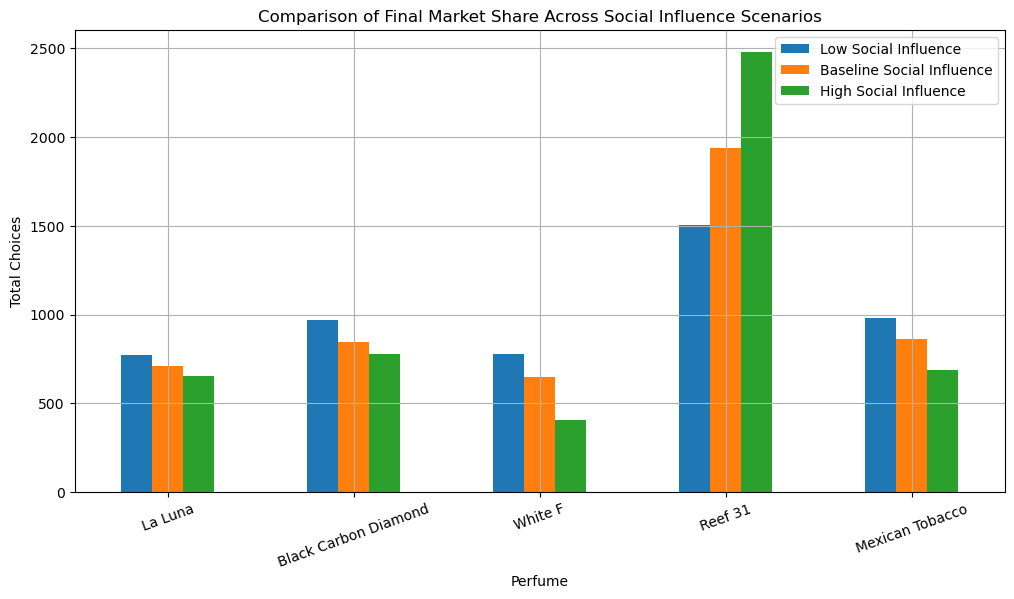

In [14]:
# Creates a grouped bar chart comparing each perfume across the low, baseline and high social influence scenarios
comparison_df.plot(kind="bar", figsize=(12, 6))

# Adds a descriptive title to the comparison graph
plt.title("Comparison of Final Market Share Across Social Influence Scenarios")

# Labels the x-axis to show that each group represents a perfume
plt.xlabel("Perfume")

# Labels the y-axis to show the cumulative number of selections
plt.ylabel("Total Choices")

# Rotates the perfume names slightly to make them easier to read
plt.xticks(rotation=20)

# Adds grid lines to make the values easier to compare
plt.grid(True)

# Displays the completed comparison graph
plt.show()

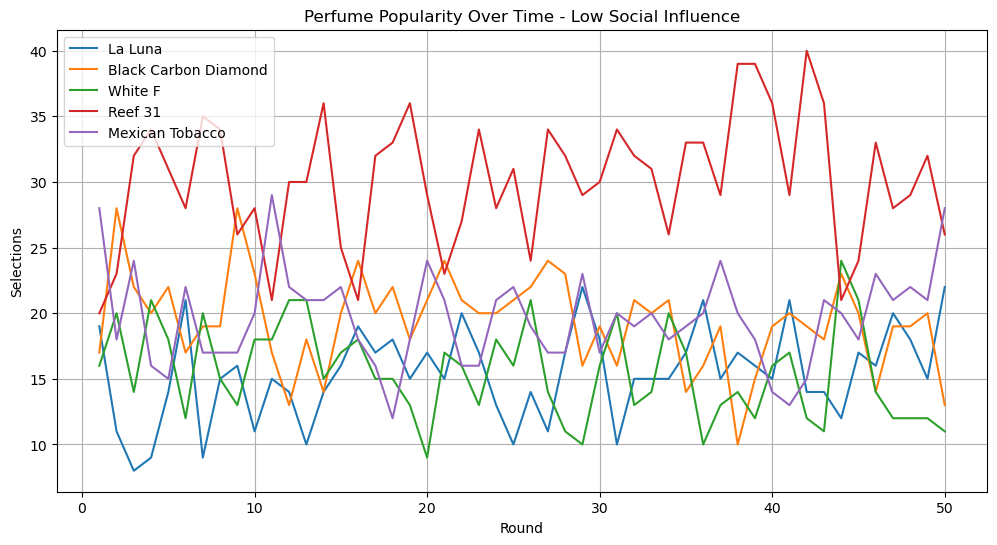

In [15]:
# Gets the round-by-round results from the low social influence scenario as a Pandas DataFrame
low_df = low_social.get_results_dataframe()

# Creates a figure for the low social influence line graph
plt.figure(figsize=(12, 6))

# Goes through each perfume and plots its selections across all 50 rounds
for perfume in low_social.perfumes:
    plt.plot(low_df["Round"], low_df[perfume.name], label=perfume.name)

# Adds a title describing the scenario being displayed
plt.title("Perfume Popularity Over Time - Low Social Influence")

# Labels the x-axis with the simulation rounds
plt.xlabel("Round")

# Labels the y-axis with the number of selections per round
plt.ylabel("Selections")

# Displays a legend so each line can be identified by perfume
plt.legend()

# Adds grid lines to make the trends easier to read
plt.grid(True)

# Displays the completed graph
plt.show()

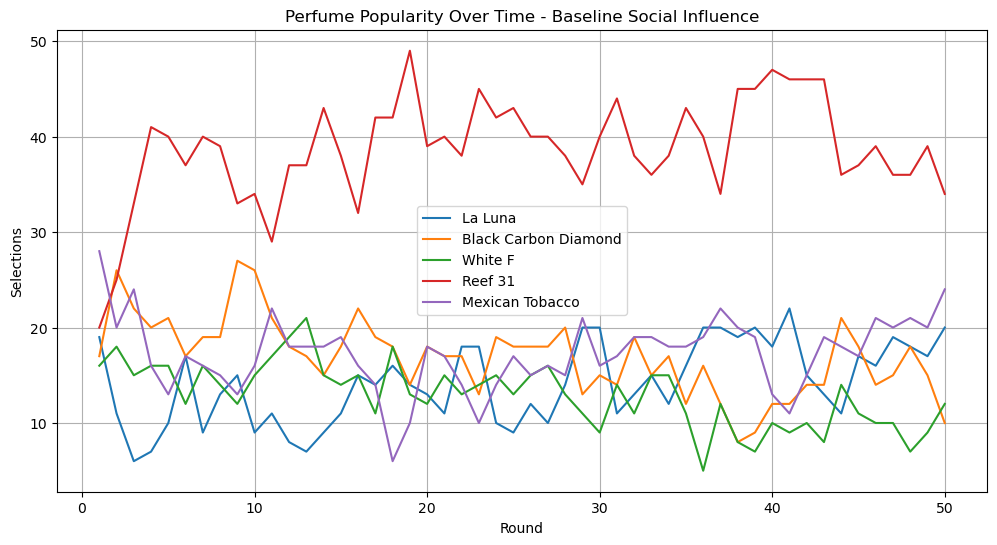

In [16]:
# Gets the round-by-round results from the baseline social influence scenario as a Pandas DataFrame
baseline_df = baseline_social.get_results_dataframe()

# Creates a figure for the baseline social influence line graph
plt.figure(figsize=(12, 6))

# Goes through each perfume and plots its selections across all 50 rounds
for perfume in baseline_social.perfumes:
    plt.plot(baseline_df["Round"], baseline_df[perfume.name], label=perfume.name)

# Adds a title describing the scenario being displayed
plt.title("Perfume Popularity Over Time - Baseline Social Influence")

# Labels the x-axis with the simulation rounds
plt.xlabel("Round")

# Labels the y-axis with the number of selections per round
plt.ylabel("Selections")

# Displays a legend so each line can be identified by perfume
plt.legend()

# Adds grid lines to make the trends easier to read
plt.grid(True)

# Displays the completed graph
plt.show()

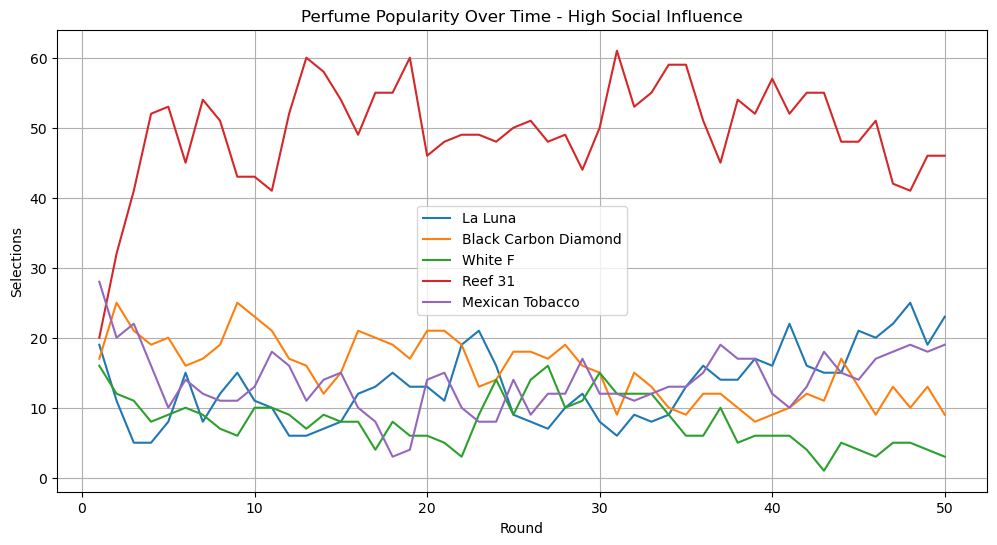

In [17]:
# Gets the round-by-round results from the high social influence scenario as a Pandas DataFrame
high_df = high_social.get_results_dataframe()

# Creates a figure for the high social influence line graph
plt.figure(figsize=(12, 6))

# Goes through each perfume and plots its selections across all 50 rounds
for perfume in high_social.perfumes:
    plt.plot(high_df["Round"], high_df[perfume.name], label=perfume.name)

# Adds a title describing the scenario being displayed
plt.title("Perfume Popularity Over Time - High Social Influence")

# Labels the x-axis with the simulation rounds
plt.xlabel("Round")

# Labels the y-axis with the number of selections per round
plt.ylabel("Selections")

# Displays a legend so each line can be identified by perfume
plt.legend()

# Adds grid lines to make the trends easier to read
plt.grid(True)

# Displays the completed graph
plt.show()

In [18]:
# Creates a scenario version of the simulation where the range of price sensitivity can be changed
class PerfumeSimulationPriceScenario:

    # Initialises the scenario with agents, rounds, random seed and a chosen price sensitivity range
    def __init__(self, num_agents=100, num_rounds=50, seed=42, price_range=(0.1, 1.0)):

        # Stores the number of consumer agents
        self.num_agents = num_agents

        # Stores the number of simulation rounds
        self.num_rounds = num_rounds

        # Stores the price sensitivity range being tested
        self.price_range = price_range

        # Sets the random seed to make the scenario reproducible under the same conditions
        random.seed(seed)

        # Defines the five available scent families
        self.scents = ["sweet", "oud", "fresh", "amber", "tobacco"]

        # Creates the same five perfume products used in the main simulation
        self.perfumes = [
            Perfume(1, "La Luna", "sweet", 130),
            Perfume(2, "Black Carbon Diamond", "oud", 110),
            Perfume(3, "White F", "fresh", 70),
            Perfume(4, "Reef 31", "amber", 70),
            Perfume(5, "Mexican Tobacco", "tobacco", 120),
        ]

        # Creates the consumer agents for this price sensitivity scenario
        self.agents = self.create_agents()

        # Creates an empty list for storing the results from each round
        self.history = []

    # Creates agents using the selected price sensitivity range
    def create_agents(self):

        # Creates an empty list for storing the agents
        agents = []

        # Creates the required number of consumer agents
        for i in range(1, self.num_agents + 1):

            # Creates an individual consumer agent
            agent = Agent(

                # Gives each agent a unique ID
                agent_id=i,

                # Randomly assigns one of the five preferred scent families
                preferred_scent=random.choice(self.scents),

                # Assigns price sensitivity from the range selected for this scenario
                price_sensitivity=round(random.uniform(self.price_range[0], self.price_range[1]), 2),

                # Keeps social susceptibility within the baseline range of 0.4 to 0.7
                social_susceptibility=round(random.uniform(0.4, 0.7), 2)
            )

            # Adds the newly created agent to the list
            agents.append(agent)

        # Returns the completed list of agents
        return agents

    # Runs the price sensitivity scenario
    def run(self):

        # Repeats the simulation for the specified number of rounds
        for round_num in range(1, self.num_rounds + 1):

            # Resets each perfume's current-round selection count to zero
            round_counts = {perfume.name: 0 for perfume in self.perfumes}

            # Allows every agent to make one perfume choice during the current round
            for agent in self.agents:

                # Uses the existing Agent decision-making method to select a perfume
                chosen_perfume = agent.choose_perfume(self.perfumes)

                # Records the perfume selection for the current round
                round_counts[chosen_perfume.name] += 1

                # Adds the selection to the perfume's cumulative total
                chosen_perfume.total_choices += 1

            # Updates each perfume's popularity using its selections from the completed round
            for perfume in self.perfumes:
                perfume.popularity = round_counts[perfume.name]

            # Creates a result row containing the round number
            row = {"Round": round_num}

            # Adds each perfume's selection count to the result row
            row.update(round_counts)

            # Stores the completed round in the simulation history
            self.history.append(row)

    # Converts the stored scenario results into a Pandas DataFrame
    def get_results_dataframe(self):
        return pd.DataFrame(self.history)

    # Returns the cumulative number of selections received by each perfume
    def get_total_choices(self):
        return {perfume.name: perfume.total_choices for perfume in self.perfumes}

In [19]:
# Creates the low price sensitivity scenario where agents have price sensitivity values from 0.1 to 0.3
low_price = PerfumeSimulationPriceScenario(
    num_agents=100,
    num_rounds=50,
    seed=42,
    price_range=(0.1, 0.3)
)

# Creates the baseline price sensitivity scenario where agents have values from 0.4 to 0.7
baseline_price = PerfumeSimulationPriceScenario(
    num_agents=100,
    num_rounds=50,
    seed=42,
    price_range=(0.4, 0.7)
)

# Creates the high price sensitivity scenario where agents have values from 0.8 to 1.0
high_price = PerfumeSimulationPriceScenario(
    num_agents=100,
    num_rounds=50,
    seed=42,
    price_range=(0.8, 1.0)
)

# Runs the low price sensitivity simulation
low_price.run()

# Runs the baseline price sensitivity simulation
baseline_price.run()

# Runs the high price sensitivity simulation
high_price.run()

In [20]:
# Creates a Pandas DataFrame to compare total perfume selections across the three price sensitivity scenarios
price_comparison_df = pd.DataFrame({

    # Adds the total selections from the low price sensitivity scenario
    "Low Price Sensitivity": low_price.get_total_choices(),

    # Adds the total selections from the baseline price sensitivity scenario
    "Baseline Price Sensitivity": baseline_price.get_total_choices(),

    # Adds the total selections from the high price sensitivity scenario
    "High Price Sensitivity": high_price.get_total_choices()
})

# Displays the completed price sensitivity comparison table
price_comparison_df

,Low Price Sensitivity,Baseline Price Sensitivity,High Price Sensitivity
La Luna,792,765,537
Black Carbon Diamond,882,839,791
White F,580,540,784
Reef 31,1844,1938,2035
Mexican Tobacco,902,918,853


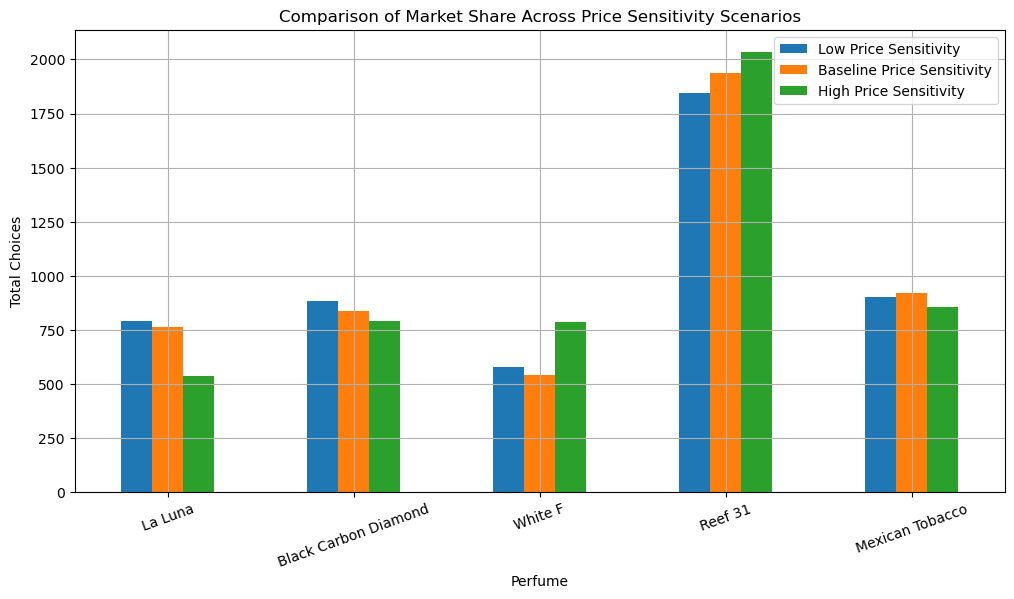

In [21]:
# Creates a grouped bar chart comparing each perfume across the three price sensitivity scenarios
price_comparison_df.plot(kind="bar", figsize=(12,6))

# Adds a title describing what the graph is comparing
plt.title("Comparison of Market Share Across Price Sensitivity Scenarios")

# Labels the x-axis with the perfume products
plt.xlabel("Perfume")

# Labels the y-axis with the cumulative number of selections
plt.ylabel("Total Choices")

# Rotates the perfume names slightly to make them easier to read
plt.xticks(rotation=20)

# Adds grid lines to make the values easier to compare
plt.grid(True)

# Displays the completed comparison graph
plt.show()